In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

In [2]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    index_even = number % 2 == 0
    index_odd = number % 2 == 1

    value = intensity.copy() + background.copy()
    value[index_even] = value[index_even] * (1 - alpha/2)
    value[index_odd] = value[index_odd] * (1 + alpha/2)
    return value


In [3]:
N_NUMBERS = 2048
N_TIMES = 250
N_FRAMES = 1
N_ITERS = 25

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

In [4]:
alpha_mean = 0.01208 * 1
alpha_std = 0.0004986

alpha = alpha_mean*(1 + alpha_std/alpha_mean*np.random.randn(1))


100%|██████████| 25/25 [00:00<00:00, 8313.45it/s]

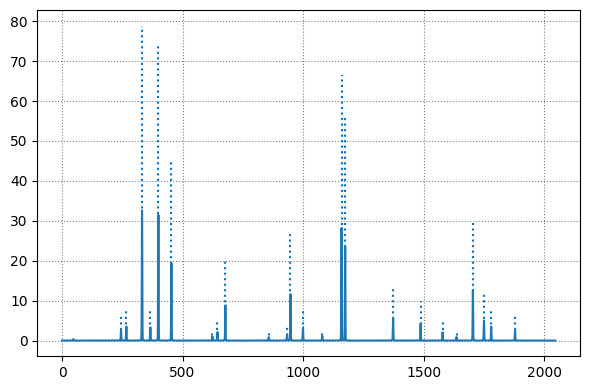

In [5]:
detector = Detector.BLPP2000

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=np.random.uniform(0, N_NUMBERS, size=(N_ITERS,)),
        intensity=10**np.random.normal(MU, SIGMA, size=(N_ITERS,)),
    ),
)
experiment = experiment.setup(
    # seed=42,
    verbose=True,
    show=True,
)

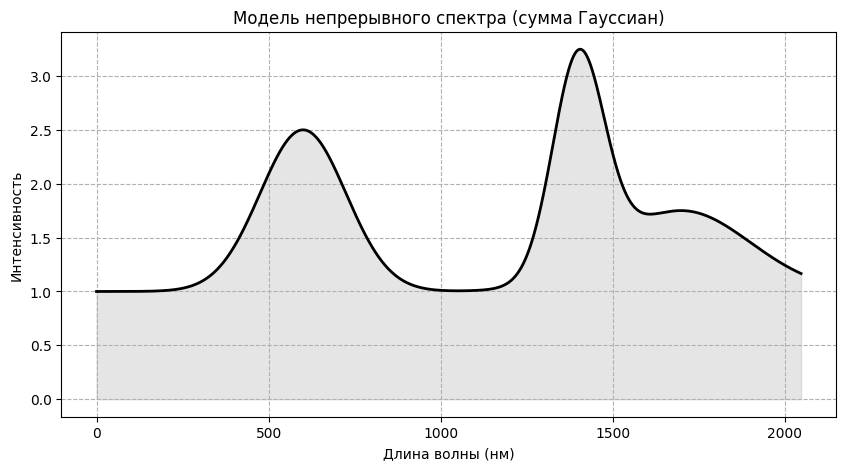

In [6]:
import numpy as np
import matplotlib.pyplot as plt

index = np.arange(N_NUMBERS)

params = [
    {"A": 2.5, "mu": 2500, "sigma": 75},
    {"A": 1.5, "mu": 600, "sigma": 125},
    {"A": 2, "mu": 1400, "sigma": 75},
    {"A": 0.75, "mu": 1700, "sigma": 200},
]

background = np.zeros(len(index), dtype=float) + 1

for p in params:
    line = p["A"] * np.exp(-((index - p["mu"])**2) / (2 * p["sigma"]**2))
    background += line


plt.figure(figsize=(10, 5))
plt.plot(index, background, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(index, background, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()


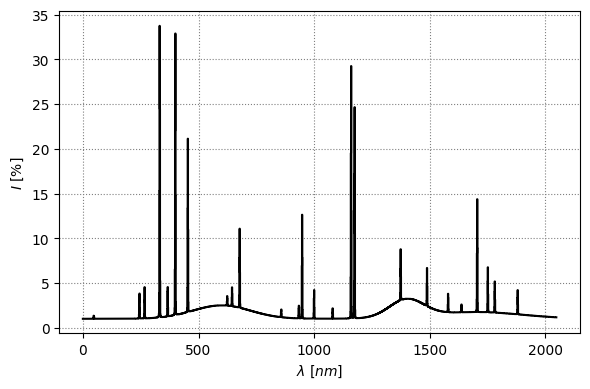

In [7]:
unicorn = experiment.run(
    is_noised=False,
    transformer=partial(transformer, background=background),
)
unicorn.show()


In [8]:
spectrum = experiment.run(
    is_noised=True,
    transformer=partial(transformer, alpha=alpha, background=background),
)

Peaks total: 30


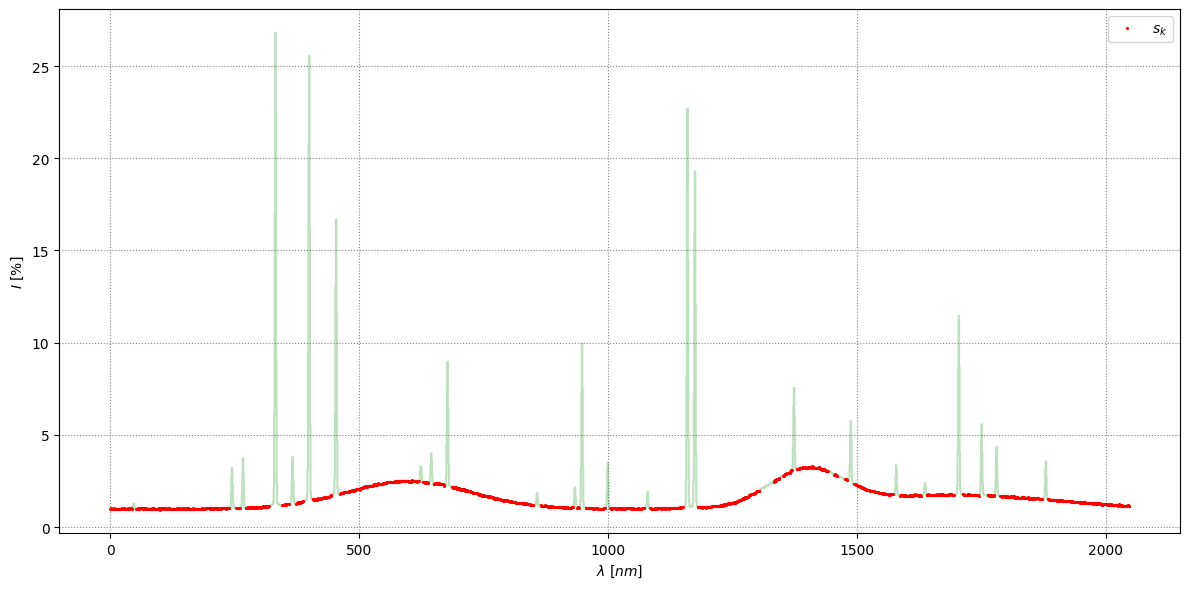

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider


peaks = draft_blinks(
    spectrum=EmittedSpectrum(
        intensity=convolve(spectrum.intensity, [.25, .5, .25], mode='mirror'),
    ),
    config=DraftBlinksConfig(
        n_counts_min=3,
        except_clipped_peak=False,
        except_sloped_peak=False,
        except_edges=True,
        amplitude_min=.1,
    ),
)
print('Peaks total: {}'.format(len(peaks)))

mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub+1] = False

#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

x = spectrum.wavelength
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')
ax.step(
    x, y,
    where='mid',
    color='green', alpha=.25,
)

x = spectrum.wavelength[mask]
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')[mask]
ax.plot(
    x, y,
    linestyle='none', color='red', alpha=1,
    marker='.', markersize=2.5,
    label='$s_{k}$',
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.legend(loc='upper right')

plt.show()



In [24]:
len(spectrum.intensity[index_even & mask])

826

2048

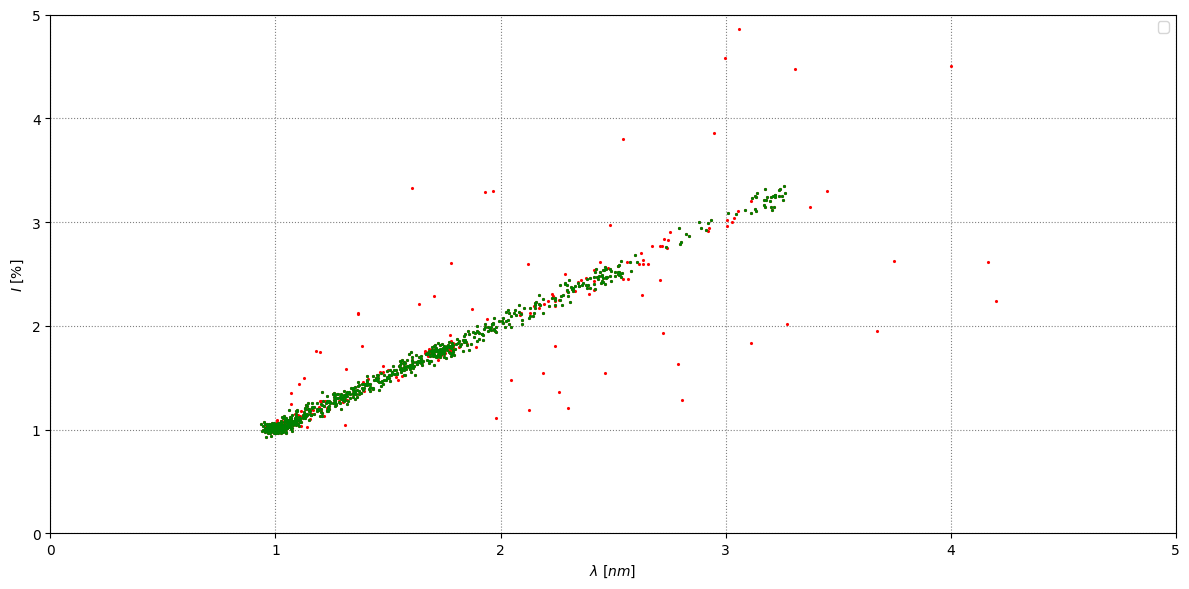

In [26]:
number = np.arange(len(spectrum.intensity))
index_even = number % 2 == 0
index_odd = number % 2 == 1

##
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

plt.plot(
    spectrum.intensity[index_even],
    spectrum.intensity[index_odd],
    linestyle='none', color='red', alpha=1,
    marker='.', markersize=2.5,
)

intensity = spectrum.intensity.copy()
intensity[~mask] = np.nan

plt.plot(
    intensity[index_even],
    intensity[index_odd],
    linestyle='none', color='green', alpha=1,
    marker='.', markersize=2.5,
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.set_xlim([0, 5])
ax.set_ylim([0, 5])

ax.legend(loc='upper right')

plt.show()

In [10]:
def calculate_loss(
    params: Array[float],
    spectrum: 'EmittedSpectrum',
    smooth: Array[R],
    mask: Array[bool],
) -> float:
    alpha, *_ = params

    corrected = spectrum.intensity.copy()
    corrected[0::2] /= 1 - alpha/2
    corrected[1::2] /= 1 + alpha/2

    noise = (corrected - smooth)[mask]
    return np.sum(noise**2)


def estimate_params(
    spectrum: 'EmittedSpectrum',
    mask: Array[bool],
) -> float:

    index_even = (np.arange(spectrum.n_numbers) % 2 == 0) & mask
    index_odd = (np.arange(spectrum.n_numbers) % 2 == 1) & mask
    R = np.mean(spectrum.intensity[index_even]) / np.mean(spectrum.intensity[index_odd])

    smooth = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')

    res = optimize.minimize(
        partial(calculate_loss, spectrum=spectrum, smooth=smooth, mask=mask),
        x0=[
            (1 - 1/R)/2,
        ],
        bounds=[
            (-.1, +.1),
        ],
        method='L-BFGS-B',
    )

    return res


In [11]:
peaks = draft_blinks(
    spectrum=EmittedSpectrum(
        intensity=convolve(spectrum.intensity, [.25, .5, .25], mode='mirror'),
    ),
    config=DraftBlinksConfig(
        n_counts_min=3,
        except_clipped_peak=False,
        except_sloped_peak=False,
        except_edges=True,
        amplitude_min=.1,
    ),
)
print('Peaks total: {}'.format(len(peaks)))

mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub+1] = False


Peaks total: 26


In [12]:
window_size = 8
max_extra = 10
min_points = 32


import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider


def update_plot(
    n: int,
    dn: int = 128,
):
    index = np.arange(max(n - dn//2, 0), min(n + dn//2, spectrum.n_numbers))

    for extra in range(max_extra):
        left = max(n - extra*window_size, 0)
        right = min(n + extra*window_size + window_size, spectrum.n_numbers)

        if sum(mask[left:right]) > min_points:
            break

    res = estimate_params(
        spectrum=EmittedSpectrum(
            intensity=spectrum.intensity[left:right],
        ),
        mask=mask[left:right],
    )
    alpha_hat, *_ = res['x']
    print(alpha_hat)

    #
    fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

    ax.step(
        spectrum.wavelength[index],
        unicorn.intensity[index],
        where='mid',
        color='black', alpha=.25,
        label='unicorn'
    )
    ax.plot(
        spectrum.wavelength[index][mask[index]],
        spectrum.intensity[index][mask[index]],
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=2.5,
    )

    ax.axvspan(
        left, right,
        color='red', alpha=.1,
    )

    y_hat = spectrum.intensity[index].copy()
    y_hat[0::2] /= 1 - alpha_hat/2
    y_hat[1::2] /= 1 + alpha_hat/2
    ax.step(
        spectrum.wavelength[index],
        y_hat,
        where='mid',
        color='red', alpha=.25,
        label='corrected',
    )

    ax.plot(
        spectrum.wavelength[index],
        unicorn.intensity[index] - y_hat,
        linestyle=':',
        color='black',
        label='difference',
    )

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$I$ [$\%$]')
    ax.grid(color='grey', linestyle=':')
    ax.legend(loc='upper right')
    
    plt.show()


interact(
    update_plot, 
    n=IntSlider(min=0, max=spectrum.n_numbers, step=1, value=1430, description='n0:')
)


interactive(children=(IntSlider(value=1430, description='n0:', max=2048), IntSlider(value=128, description='dn…

<function __main__.update_plot(n: int, dn: int = 128)>

In [13]:
alpha_hat = np.zeros(spectrum.n_numbers)
for n in tqdm(range(spectrum.n_numbers)):

    for extra in range(max_extra):
        left = max(n - extra*window_size, 0)
        right = min(n + (extra + 1)*window_size, spectrum.n_numbers)

        if sum(mask[left:right]) > min_points:
            break

    alpha_hat[n] = estimate_params(
        spectrum=EmittedSpectrum(
            intensity=spectrum.intensity[left:right],
        ),
        mask=mask[left:right],
    )['x'][0]


100%|██████████| 2048/2048 [00:03<00:00, 547.68it/s]


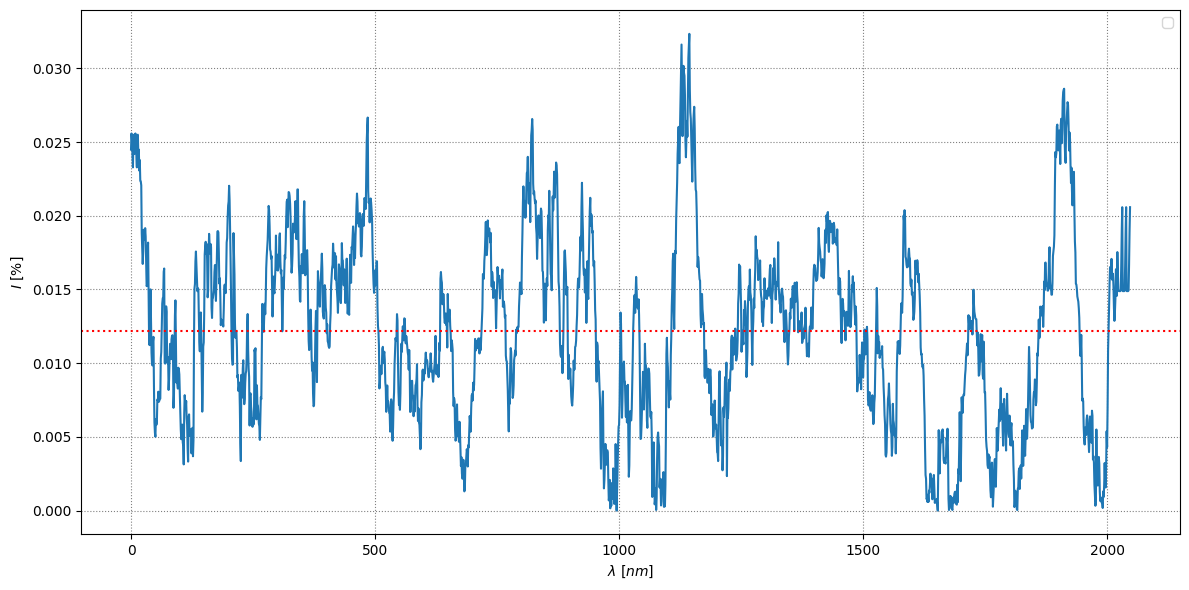

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

plt.plot(np.abs(alpha_hat))
plt.axhline(
    alpha[0],
    linestyle=':',
    color='red',
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(color='grey', linestyle=':')
ax.legend(loc='upper right')

plt.show()
